# 08 — Backward Factor Trace on a Tiny Vision Transformer

This notebook tests whether the **Backward Factor Trace** algorithm (introduced in NB02 for MLPs, extended to CNNs in NB07) transfers to transformer architectures.

**Setup:** A tiny ViT is trained on MNIST even/odd (same binary task as NB02). We then run the backward trace through the FFN sublayers of each transformer block, using the **CLS token activation** as the per-sample feature vector at each layer boundary.

**Key adaptation:** The algorithm works on any `(W, act_input)` pair. Transformer FFN sublayers are standard linear layers — no modification needed. The only choice is which token to trace (CLS) and which layers to include (FFN only; attention is left for future work).

## 1. Imports & Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib

from src.factorization import trace_single_layer
from src.data_utils import get_mnist_loaders
from src.training import label_transform_even_odd
from src.plot_utils import plot_scaffold_graph

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cpu


## 2. Dataset

In [2]:
train_loader, test_loader = get_mnist_loaders(batch_size=256, root='../data/')
CLASS_NAMES = {0: 'even', 1: 'odd'}
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 235 | Test batches: 40


## 3. Tiny ViT Architecture

```
28×28 image → 16 patches of 7×7 → embed (49→64) + CLS + pos_embed
TransformerBlock × 2:
  LN → MultiHeadAttention(dim=64, heads=2) → residual
  LN → FFN: Linear(64→128) → GELU → Linear(128→64) → residual
LN → CLS token → Linear(64, 2) → log_softmax
```

Total ~100k parameters. Each `TransformerBlock` stores FFN intermediates when `capture=True`.

In [3]:
class PatchEmbedder(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_channels=1, embed_dim=64):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2   # 16
        patch_dim = in_channels * patch_size * patch_size  # 49
        self.proj = nn.Linear(patch_dim, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size
        x = x.unfold(2, p, p).unfold(3, p, p)         # (B, C, H/p, W/p, p, p)
        x = x.contiguous().view(B, C, -1, p * p)       # (B, C, n_patches, p*p)
        x = x.permute(0, 2, 1, 3).contiguous().view(B, -1, C * p * p)  # (B, n_patches, C*p*p)
        return self.proj(x)                             # (B, n_patches, embed_dim)


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim=64, n_heads=2, ffn_dim=128, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, n_heads, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.ffn1 = nn.Linear(embed_dim, ffn_dim)
        self.ffn2 = nn.Linear(ffn_dim, embed_dim)
        self.drop = nn.Dropout(dropout)
        self._capture = False
        self._ffn1_in = None
        self._ffn1_out = None
        self._ffn2_in = None
        self._ffn2_out = None
        self._attn_weights = None

    def forward(self, x):
        h = self.ln1(x)
        attn_out, attn_w = self.attn(h, h, h,
                                     need_weights=self._capture,
                                     average_attn_weights=False)
        if self._capture:
            self._attn_weights = attn_w.detach()   # (B, heads, T, T)
        x = x + attn_out
        h = self.ln2(x)
        if self._capture:
            self._ffn1_in = h.detach()
        h2 = F.gelu(self.ffn1(h))
        if self._capture:
            self._ffn1_out = h2.detach()
            self._ffn2_in = h2.detach()
        h3 = self.ffn2(h2)
        if self._capture:
            self._ffn2_out = h3.detach()
        x = x + self.drop(h3)
        return x


class TinyViT(nn.Module):
    def __init__(self, img_size=28, patch_size=7, in_channels=1,
                 embed_dim=64, n_heads=2, ffn_dim=128, n_blocks=2, n_classes=2):
        super().__init__()
        self.patch_embed = PatchEmbedder(img_size, patch_size, in_channels, embed_dim)
        n_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, n_heads, ffn_dim) for _ in range(n_blocks)
        ])
        self.ln = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, n_classes)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x, capture=False):
        for blk in self.blocks:
            blk._capture = capture
        B = x.shape[0]
        tokens = torch.cat([self.cls_token.expand(B, -1, -1),
                             self.patch_embed(x)], dim=1) + self.pos_embed
        for blk in self.blocks:
            tokens = blk(tokens)
        return F.log_softmax(self.head(self.ln(tokens[:, 0])), dim=1)


model = TinyViT().to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 71,554


## 4. Training

Epoch  1 | loss 0.3027 | test acc 0.9451
Epoch  2 | loss 0.1182 | test acc 0.9692
Epoch  3 | loss 0.0891 | test acc 0.9735
Epoch  4 | loss 0.0719 | test acc 0.9781
Epoch  5 | loss 0.0630 | test acc 0.9793
Epoch  6 | loss 0.0562 | test acc 0.9804
Epoch  7 | loss 0.0512 | test acc 0.9812
Epoch  8 | loss 0.0475 | test acc 0.9820
Epoch  9 | loss 0.0434 | test acc 0.9832
Epoch 10 | loss 0.0395 | test acc 0.9833
Epoch 11 | loss 0.0392 | test acc 0.9819
Epoch 12 | loss 0.0330 | test acc 0.9818


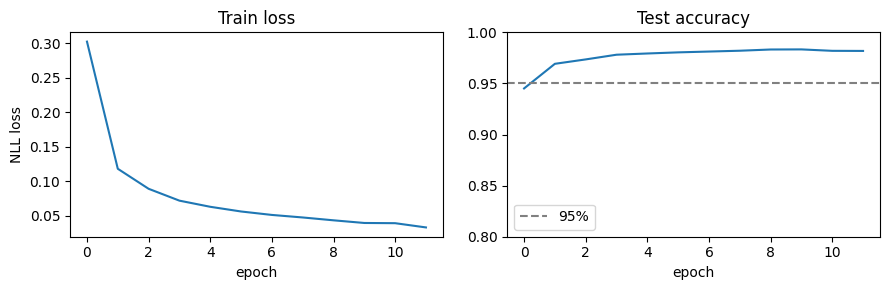

In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.NLLLoss()
N_EPOCHS = 12
train_losses, test_accs = [], []

for epoch in range(N_EPOCHS):
    model.train()
    total_loss = 0.0
    for imgs, digits in train_loader:
        imgs = imgs.to(device)
        labels = label_transform_even_odd(digits).to(device)
        loss = criterion(model(imgs), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model.eval()
    n_correct = 0
    with torch.no_grad():
        for imgs, digits in test_loader:
            imgs = imgs.to(device)
            labels = label_transform_even_odd(digits).to(device)
            n_correct += (model(imgs).argmax(1) == labels).sum().item()
    acc = n_correct / len(test_loader.dataset)
    train_losses.append(total_loss / len(train_loader))
    test_accs.append(acc)
    print(f'Epoch {epoch+1:2d} | loss {train_losses[-1]:.4f} | test acc {acc:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.plot(train_losses)
ax1.set(title='Train loss', xlabel='epoch', ylabel='NLL loss')
ax2.plot(test_accs)
ax2.axhline(0.95, ls='--', color='gray', label='95%')
ax2.set(title='Test accuracy', xlabel='epoch', ylim=(0.8, 1.0))
ax2.legend()
plt.tight_layout()
plt.show()

## 5. Activation Collection

Run the test set through the model with `capture=True`. For each correctly-classified sample,
extract the **CLS token** activation at every FFN layer boundary. This gives `(n_samples, dim)`
arrays — identical in shape to what `trace_single_layer` expects from an MLP.

In [5]:
model.eval()
all_images, all_targets, all_digits = [], [], []
ffn_acts = {k: [] for k in [
    'b0_f1_in', 'b0_f1_out', 'b0_f2_in', 'b0_f2_out',
    'b1_f1_in', 'b1_f1_out', 'b1_f2_in', 'b1_f2_out',
]}

_capture_map = [
    ('b0_f1_in',  model.blocks[0], '_ffn1_in'),
    ('b0_f1_out', model.blocks[0], '_ffn1_out'),
    ('b0_f2_in',  model.blocks[0], '_ffn2_in'),
    ('b0_f2_out', model.blocks[0], '_ffn2_out'),
    ('b1_f1_in',  model.blocks[1], '_ffn1_in'),
    ('b1_f1_out', model.blocks[1], '_ffn1_out'),
    ('b1_f2_in',  model.blocks[1], '_ffn2_in'),
    ('b1_f2_out', model.blocks[1], '_ffn2_out'),
]

with torch.no_grad():
    for imgs, digits in test_loader:
        imgs = imgs.to(device)
        labels = label_transform_even_odd(digits)
        logits = model(imgs, capture=True)
        mask = (logits.argmax(1).cpu() == labels)
        if not mask.any():
            continue
        for key, blk, attr in _capture_map:
            tensor = getattr(blk, attr)          # (B, T, D)
            ffn_acts[key].append(tensor[mask, 0].cpu().numpy())  # CLS token only
        all_images.append(imgs[mask].cpu().numpy())
        all_targets.append(labels[mask].numpy())
        all_digits.append(digits[mask].numpy())

for k in ffn_acts:
    ffn_acts[k] = np.concatenate(ffn_acts[k], axis=0)
all_images  = np.concatenate(all_images,  axis=0)
all_targets = np.concatenate(all_targets, axis=0)
all_digits  = np.concatenate(all_digits,  axis=0)

print(f'Collected {len(all_targets)} correctly-classified test samples')
for k, v in ffn_acts.items():
    print(f'  {k}: {v.shape}')

Collected 9818 correctly-classified test samples
  b0_f1_in: (9818, 64)
  b0_f1_out: (9818, 128)
  b0_f2_in: (9818, 128)
  b0_f2_out: (9818, 64)
  b1_f1_in: (9818, 64)
  b1_f1_out: (9818, 128)
  b1_f2_in: (9818, 128)
  b1_f2_out: (9818, 64)


## 6. Backward Factor Trace

We trace 4 FFN linear layers in reverse order, calling `trace_single_layer` from
`src/factorization` at each step — exactly as `dfs_trace` does for an MLP, but
with the CLS token activations and directly extracted weight matrices.

```
B1-FFN2 (128→64) ← B1-FFN1 (64→128) ← B0-FFN2 (128→64) ← B0-FFN1 (64→128)
```

Stimulus weights start uniform and are propagated backward; neuron weights are derived
from the top NMF factor's neural loading reshaped to `(n_out, n_in).sum(axis=0)`.

In [6]:
# Weight matrices (move to CPU numpy)
W_b0_f1 = model.blocks[0].ffn1.weight.detach().cpu().numpy()  # (128, 64)
W_b0_f2 = model.blocks[0].ffn2.weight.detach().cpu().numpy()  # (64, 128)
W_b1_f1 = model.blocks[1].ffn1.weight.detach().cpu().numpy()  # (128, 64)
W_b1_f2 = model.blocks[1].ffn2.weight.detach().cpu().numpy()  # (64, 128)

LAYER_LABELS = ['B0-FFN1', 'B0-FFN2', 'B1-FFN1', 'B1-FFN2']
layers = [
    (W_b0_f1, ffn_acts['b0_f1_in']),
    (W_b0_f2, ffn_acts['b0_f2_in']),
    (W_b1_f1, ffn_acts['b1_f1_in']),
    (W_b1_f2, ffn_acts['b1_f2_in']),
]

N_SAMPLES = len(all_targets)
stimulus_weights = np.ones(N_SAMPLES)
neuron_weights   = None
trace_results    = []   # populated last-layer-first

for l_idx in reversed(range(len(layers))):
    W, act_in = layers[l_idx]
    img_f, neu_f, lams, joint, neg_img_f, neg_neu_f, neg_lams = trace_single_layer(
        W, act_in, stimulus_weights,
        k_max=15, method='structural', threshold=0.90,
        neuron_weights=neuron_weights,
    )
    trace_results.append({
        'layer_idx': l_idx,
        'label': LAYER_LABELS[l_idx],
        'W': W,
        'img_factors':       img_f,
        'neural_factors':    neu_f,
        'lambdas':           lams,
        'neg_img_factors':   neg_img_f,
        'neg_neural_factors': neg_neu_f,
        'neg_lambdas':       neg_lams,
        'stimulus_weights_in': stimulus_weights.copy(),
    })
    # Propagate backward
    n_out, n_in = W.shape
    neuron_weights = neu_f[:, 0].reshape(n_out, n_in).sum(axis=0)
    target = neuron_weights / (np.linalg.norm(neuron_weights) + 1e-12)
    stimulus_weights = np.clip(act_in @ target, 0, None)
    print(f'{LAYER_LABELS[l_idx]}: k*={len(lams)}  λ = {np.round(lams, 3)}')

B1-FFN2: k*=14  λ = [56.779 55.248 51.299 48.314 44.896 44.035 40.764 34.404 34.316 31.455
 29.781 25.229 25.122 24.219]
B1-FFN1: k*=14  λ = [192.128 185.846 158.421 143.709 142.283 131.778 127.079 122.517 116.549
 112.952 111.991 105.692 103.827 100.393]
B0-FFN2: k*=14  λ = [46.655 40.265 37.208 35.963 27.549 26.148 24.049 23.181 20.673 20.651
 19.426 16.37  15.084 14.948]
B0-FFN1: k*=14  λ = [20.107 18.583 16.407 16.342 16.294 15.537 15.251 15.1   13.869 13.45
 13.305 13.217 11.896 10.259]


## 7a. Per-Layer Factor Summary Plots

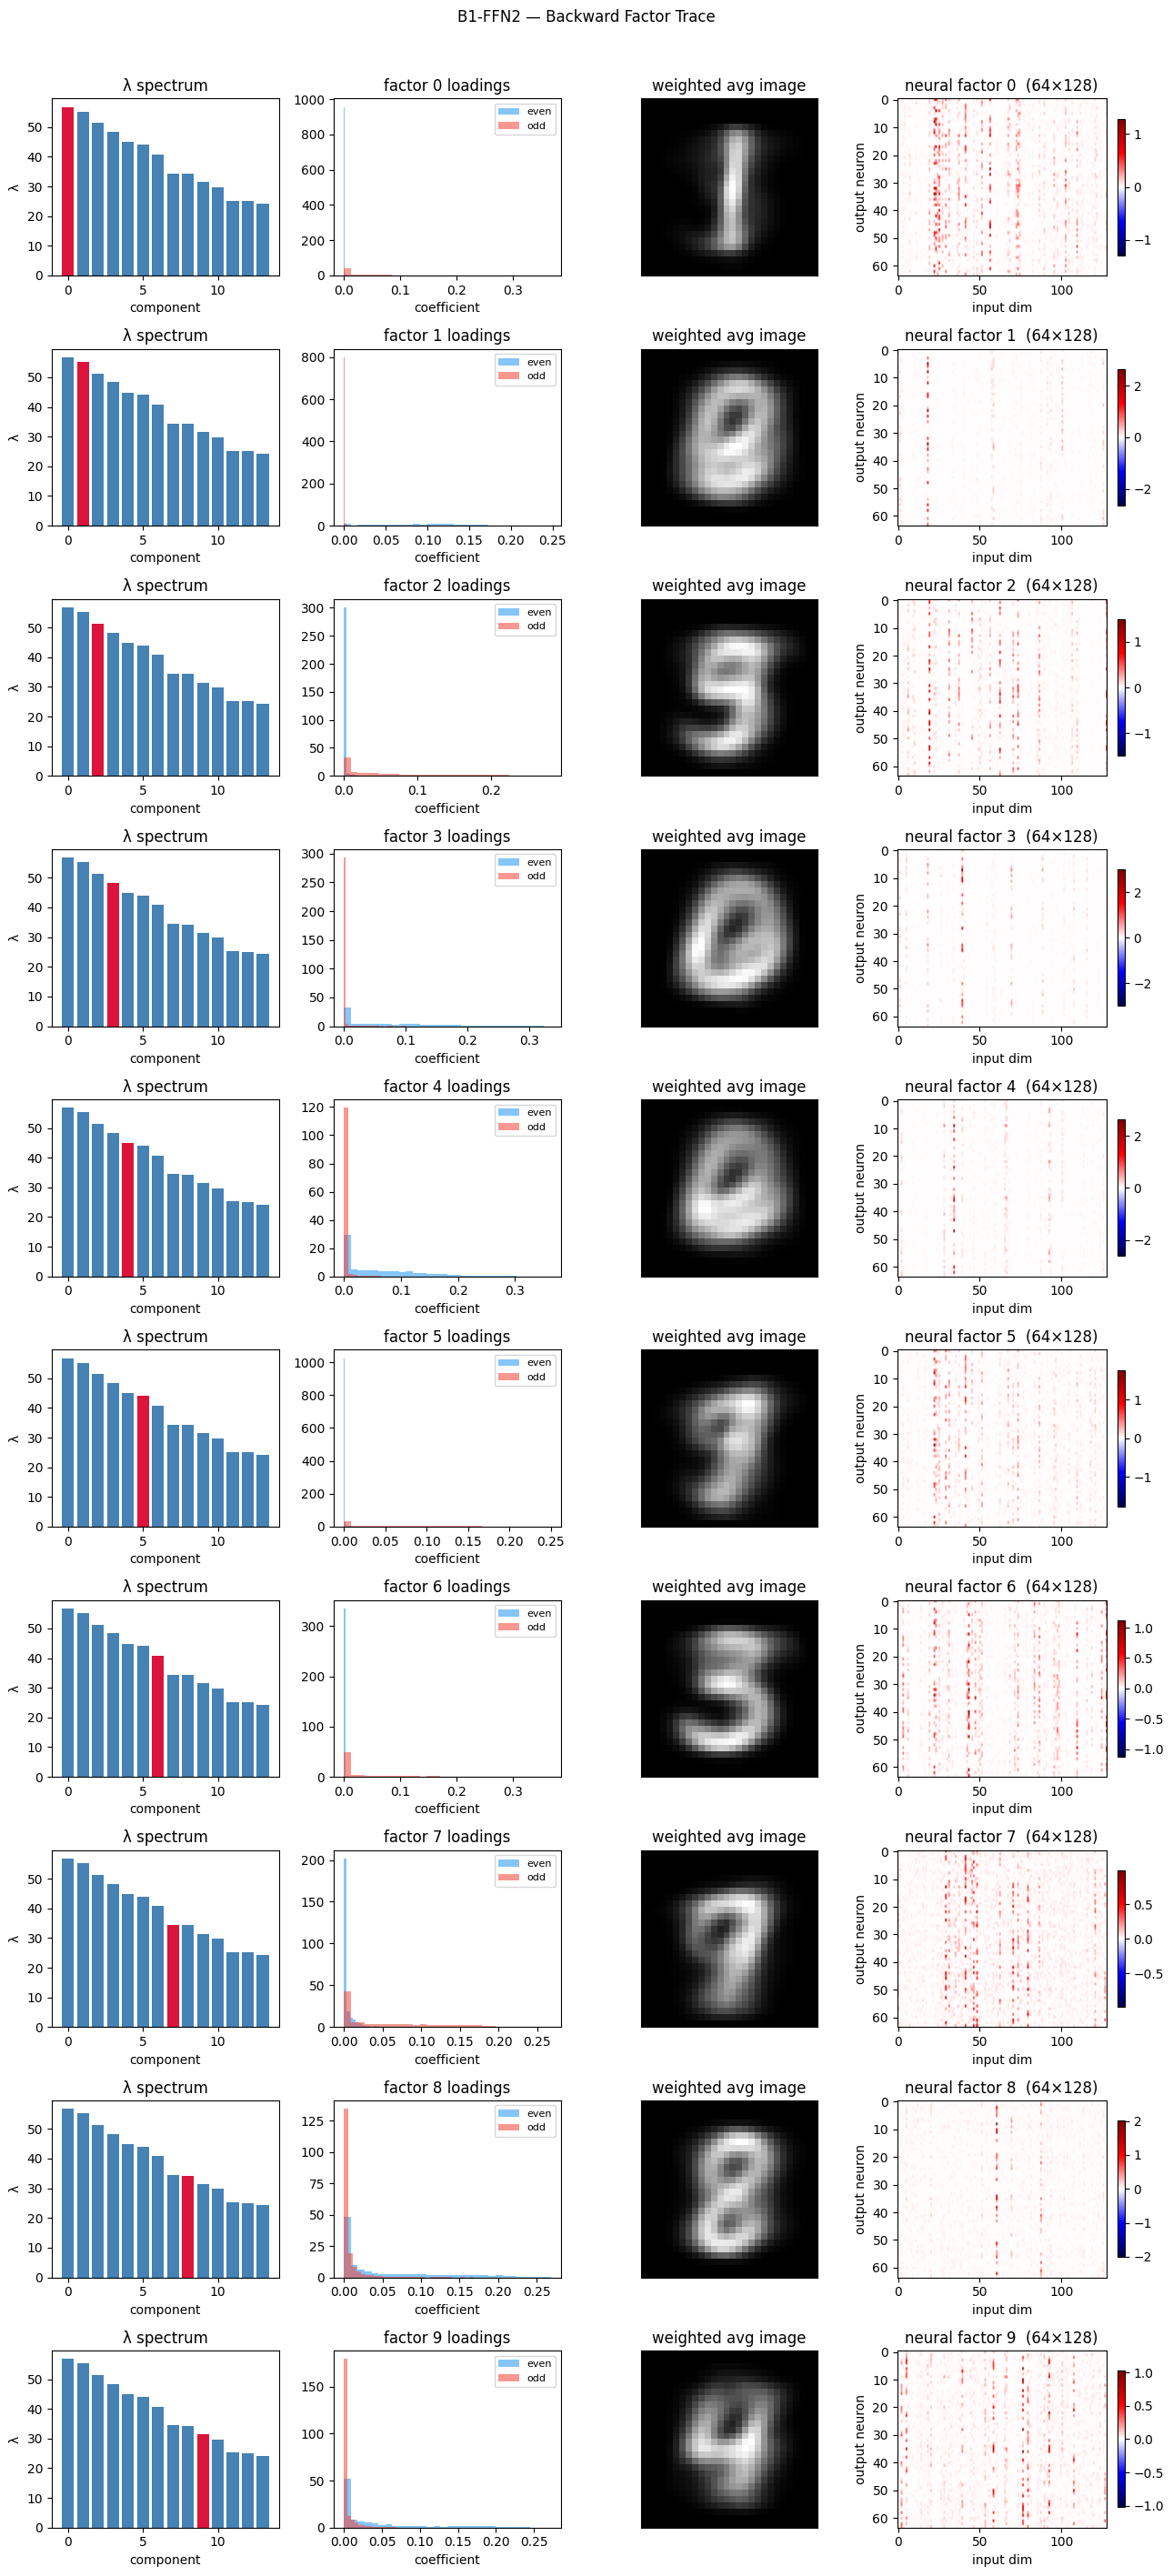

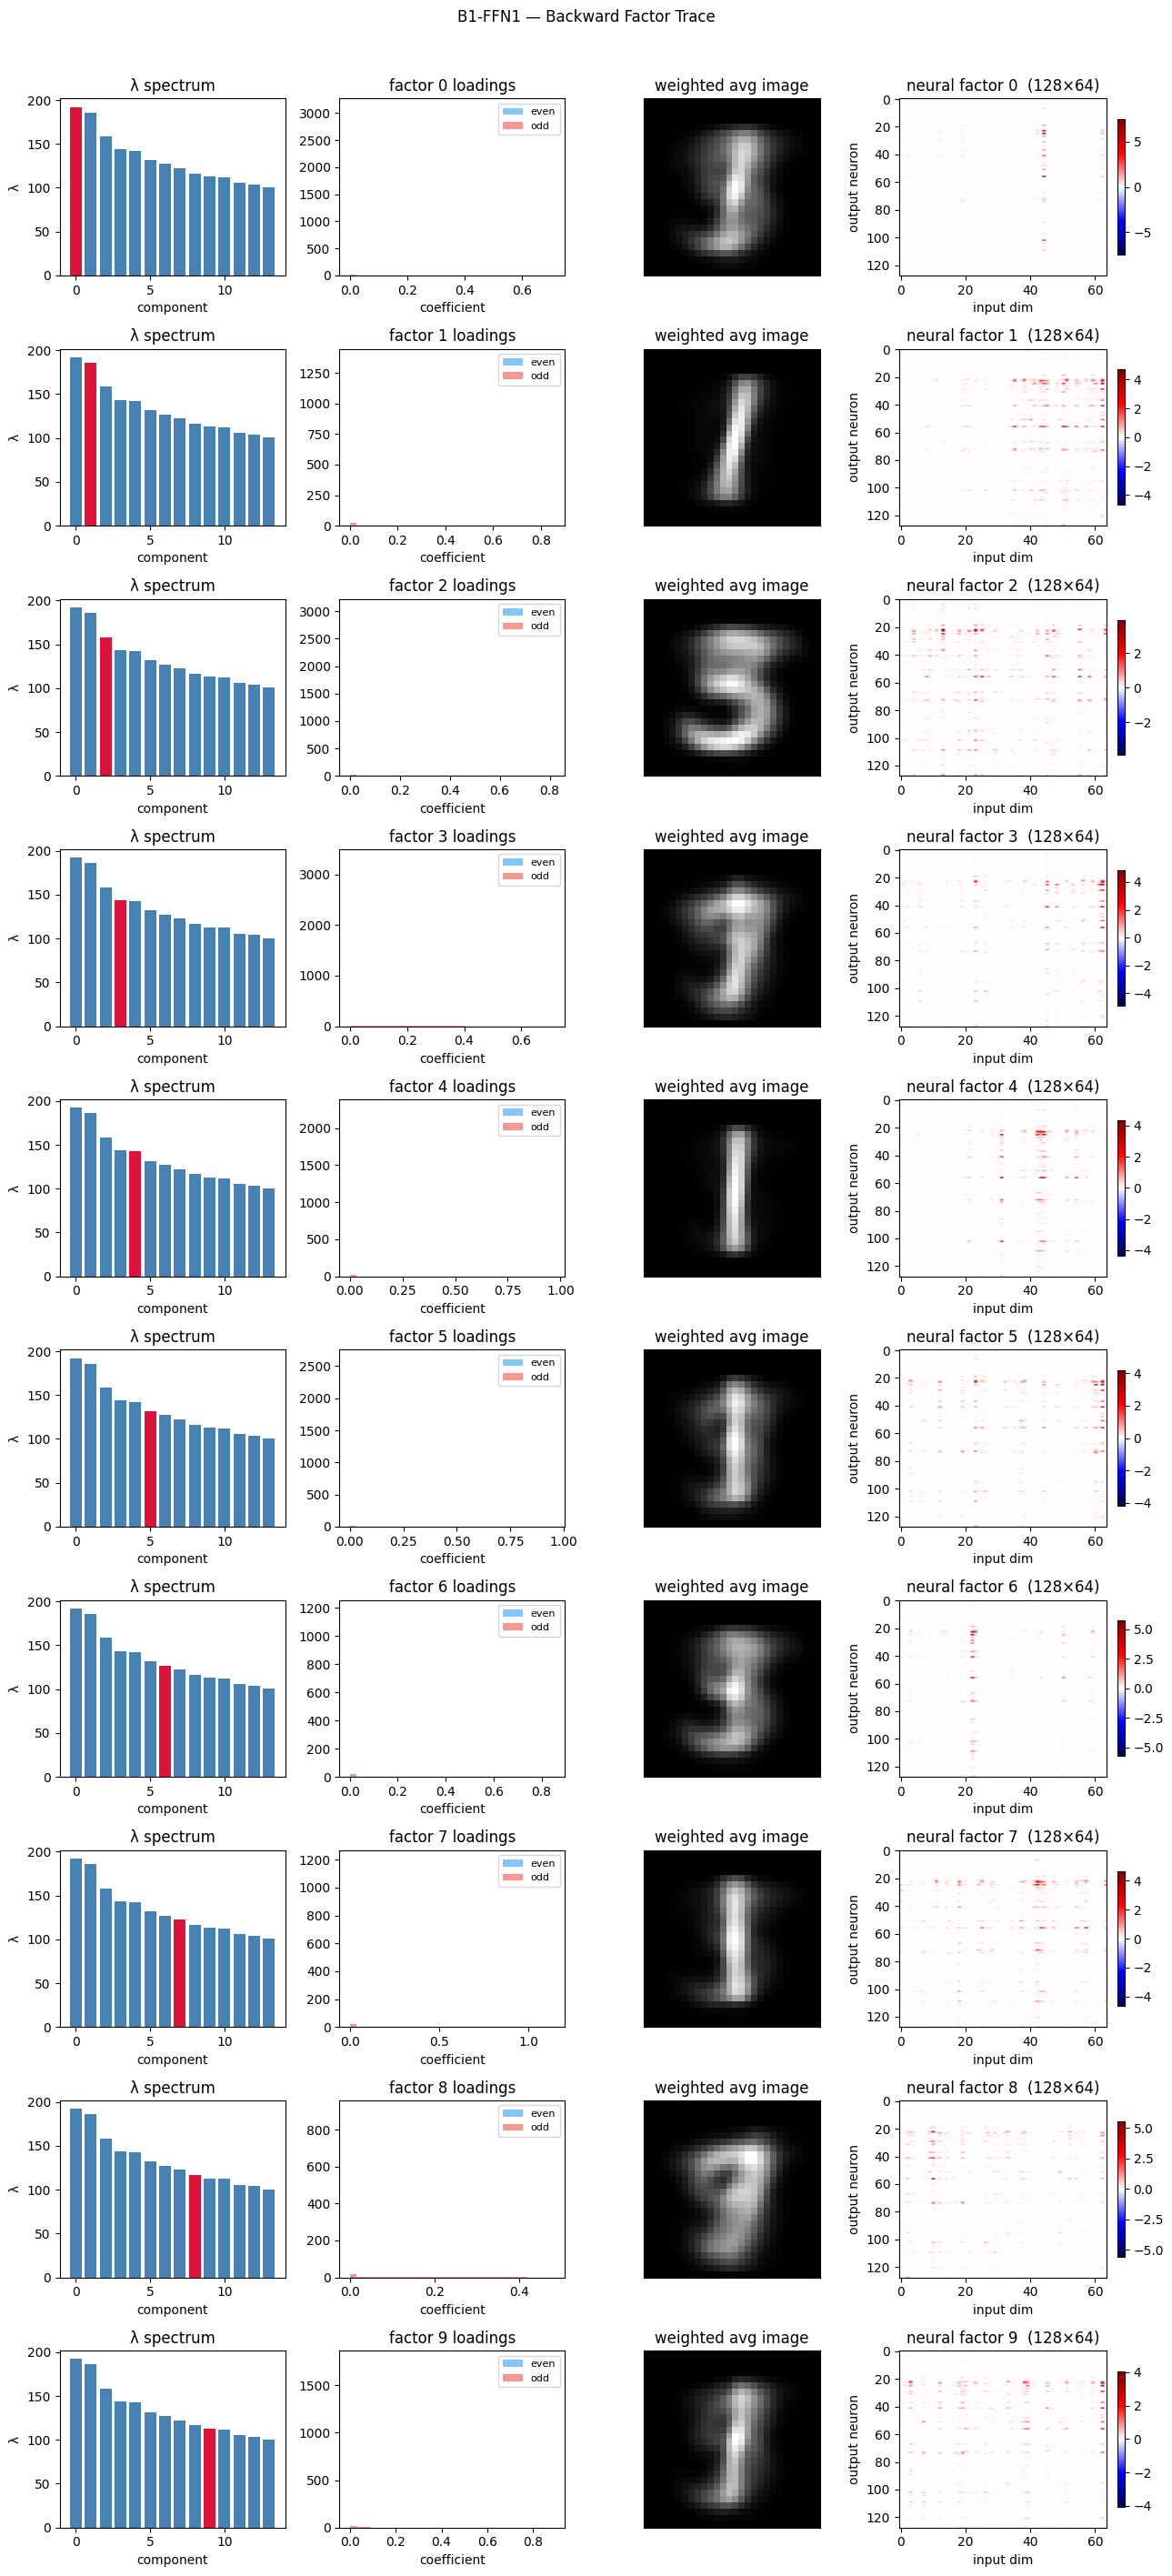

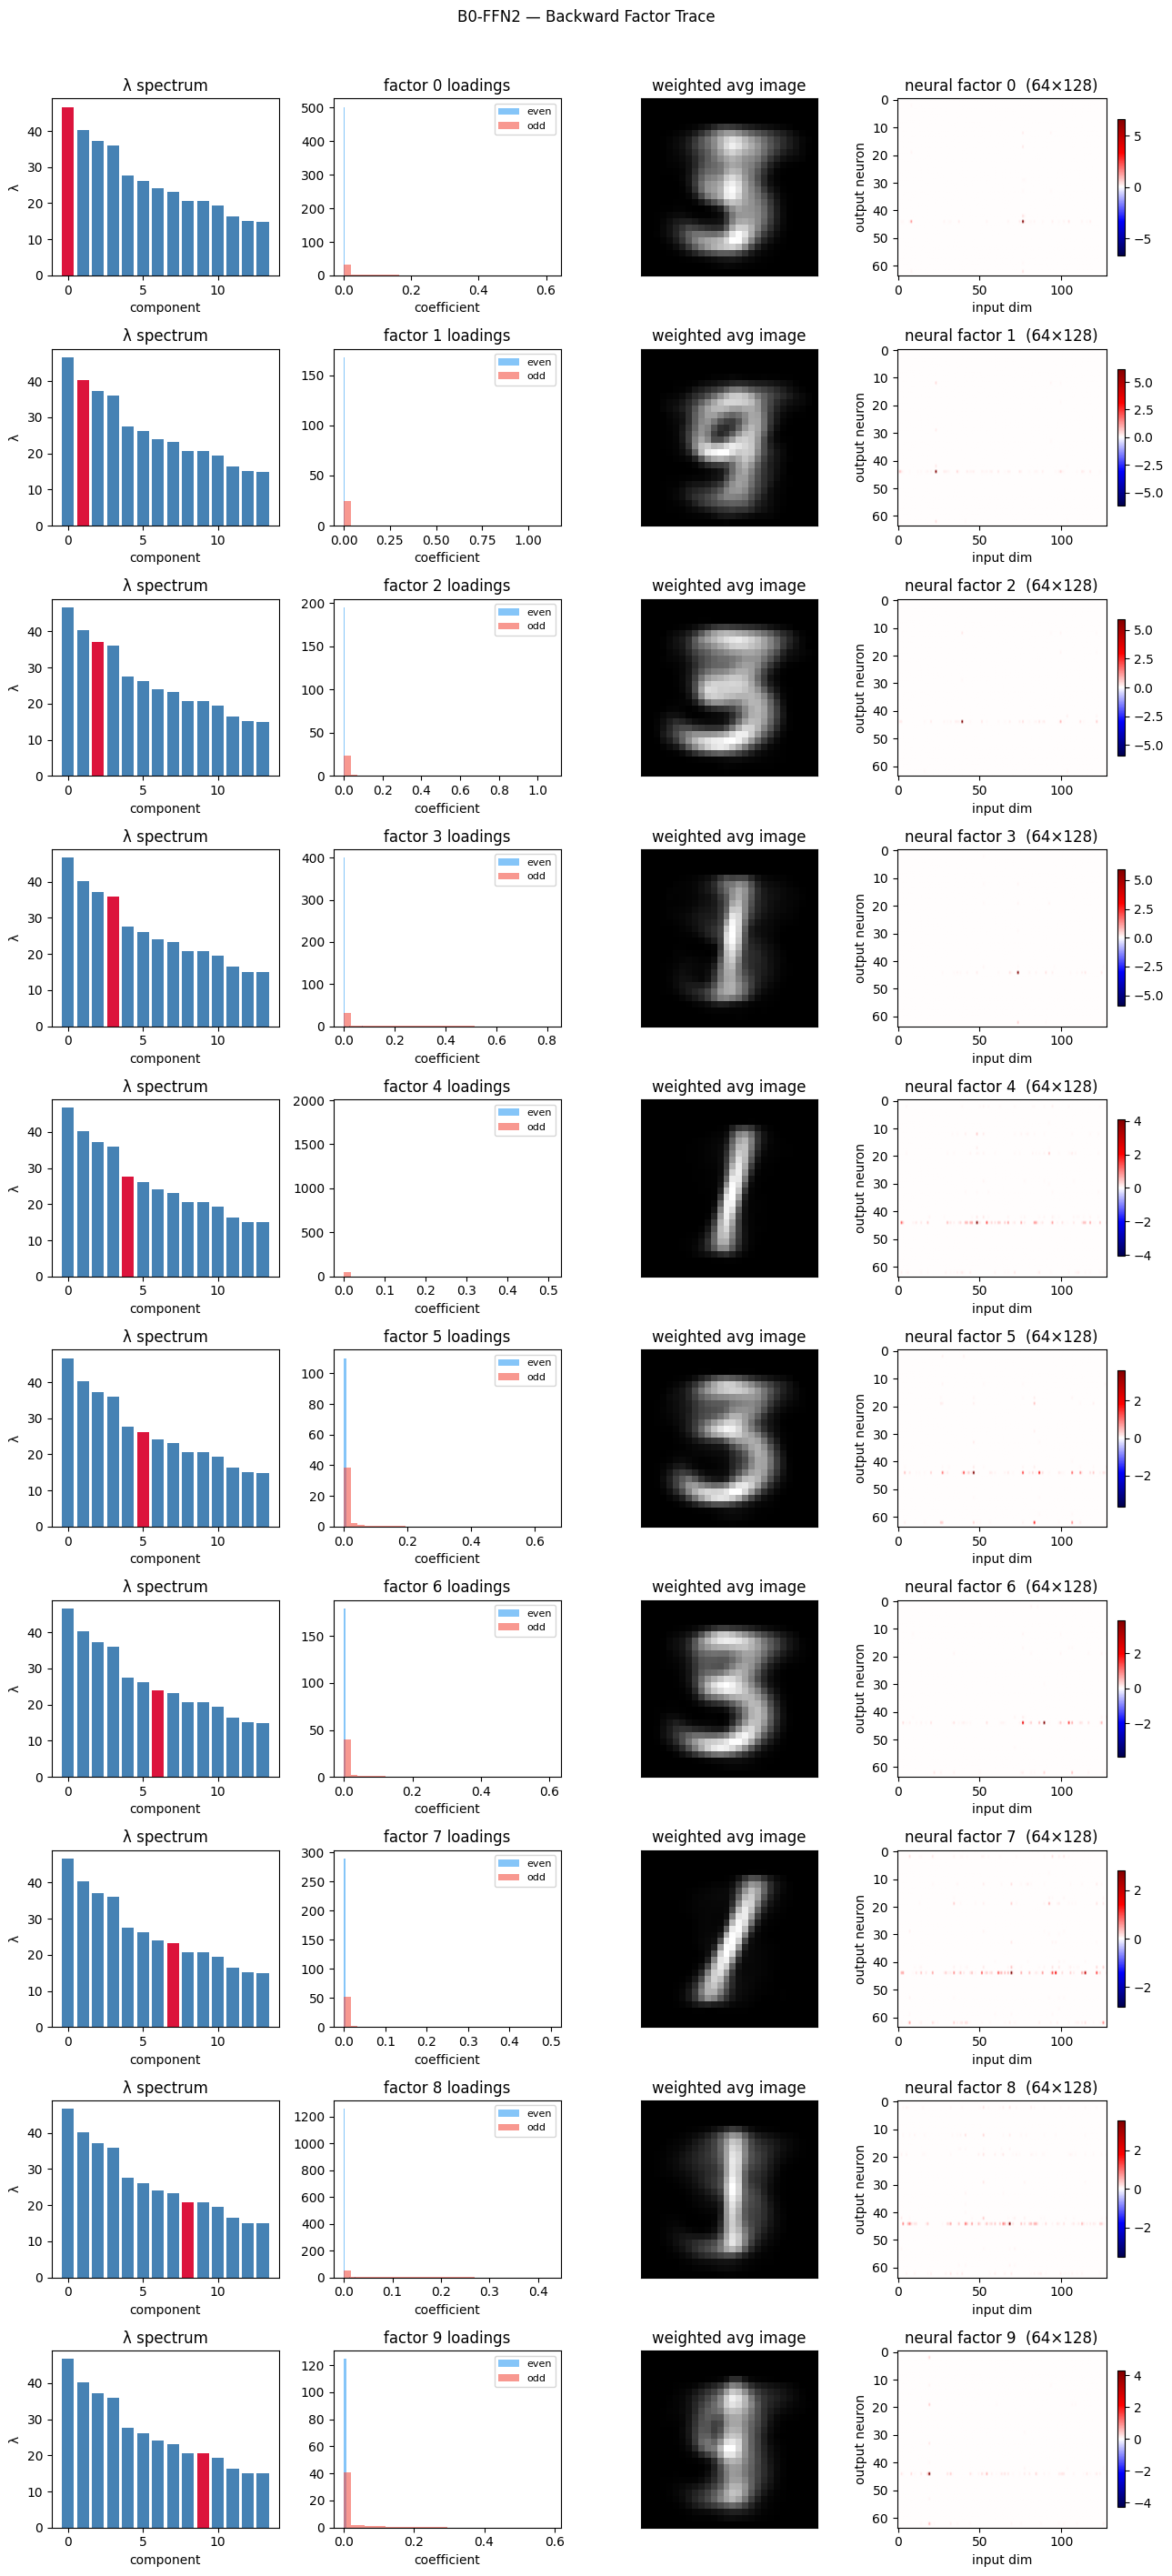

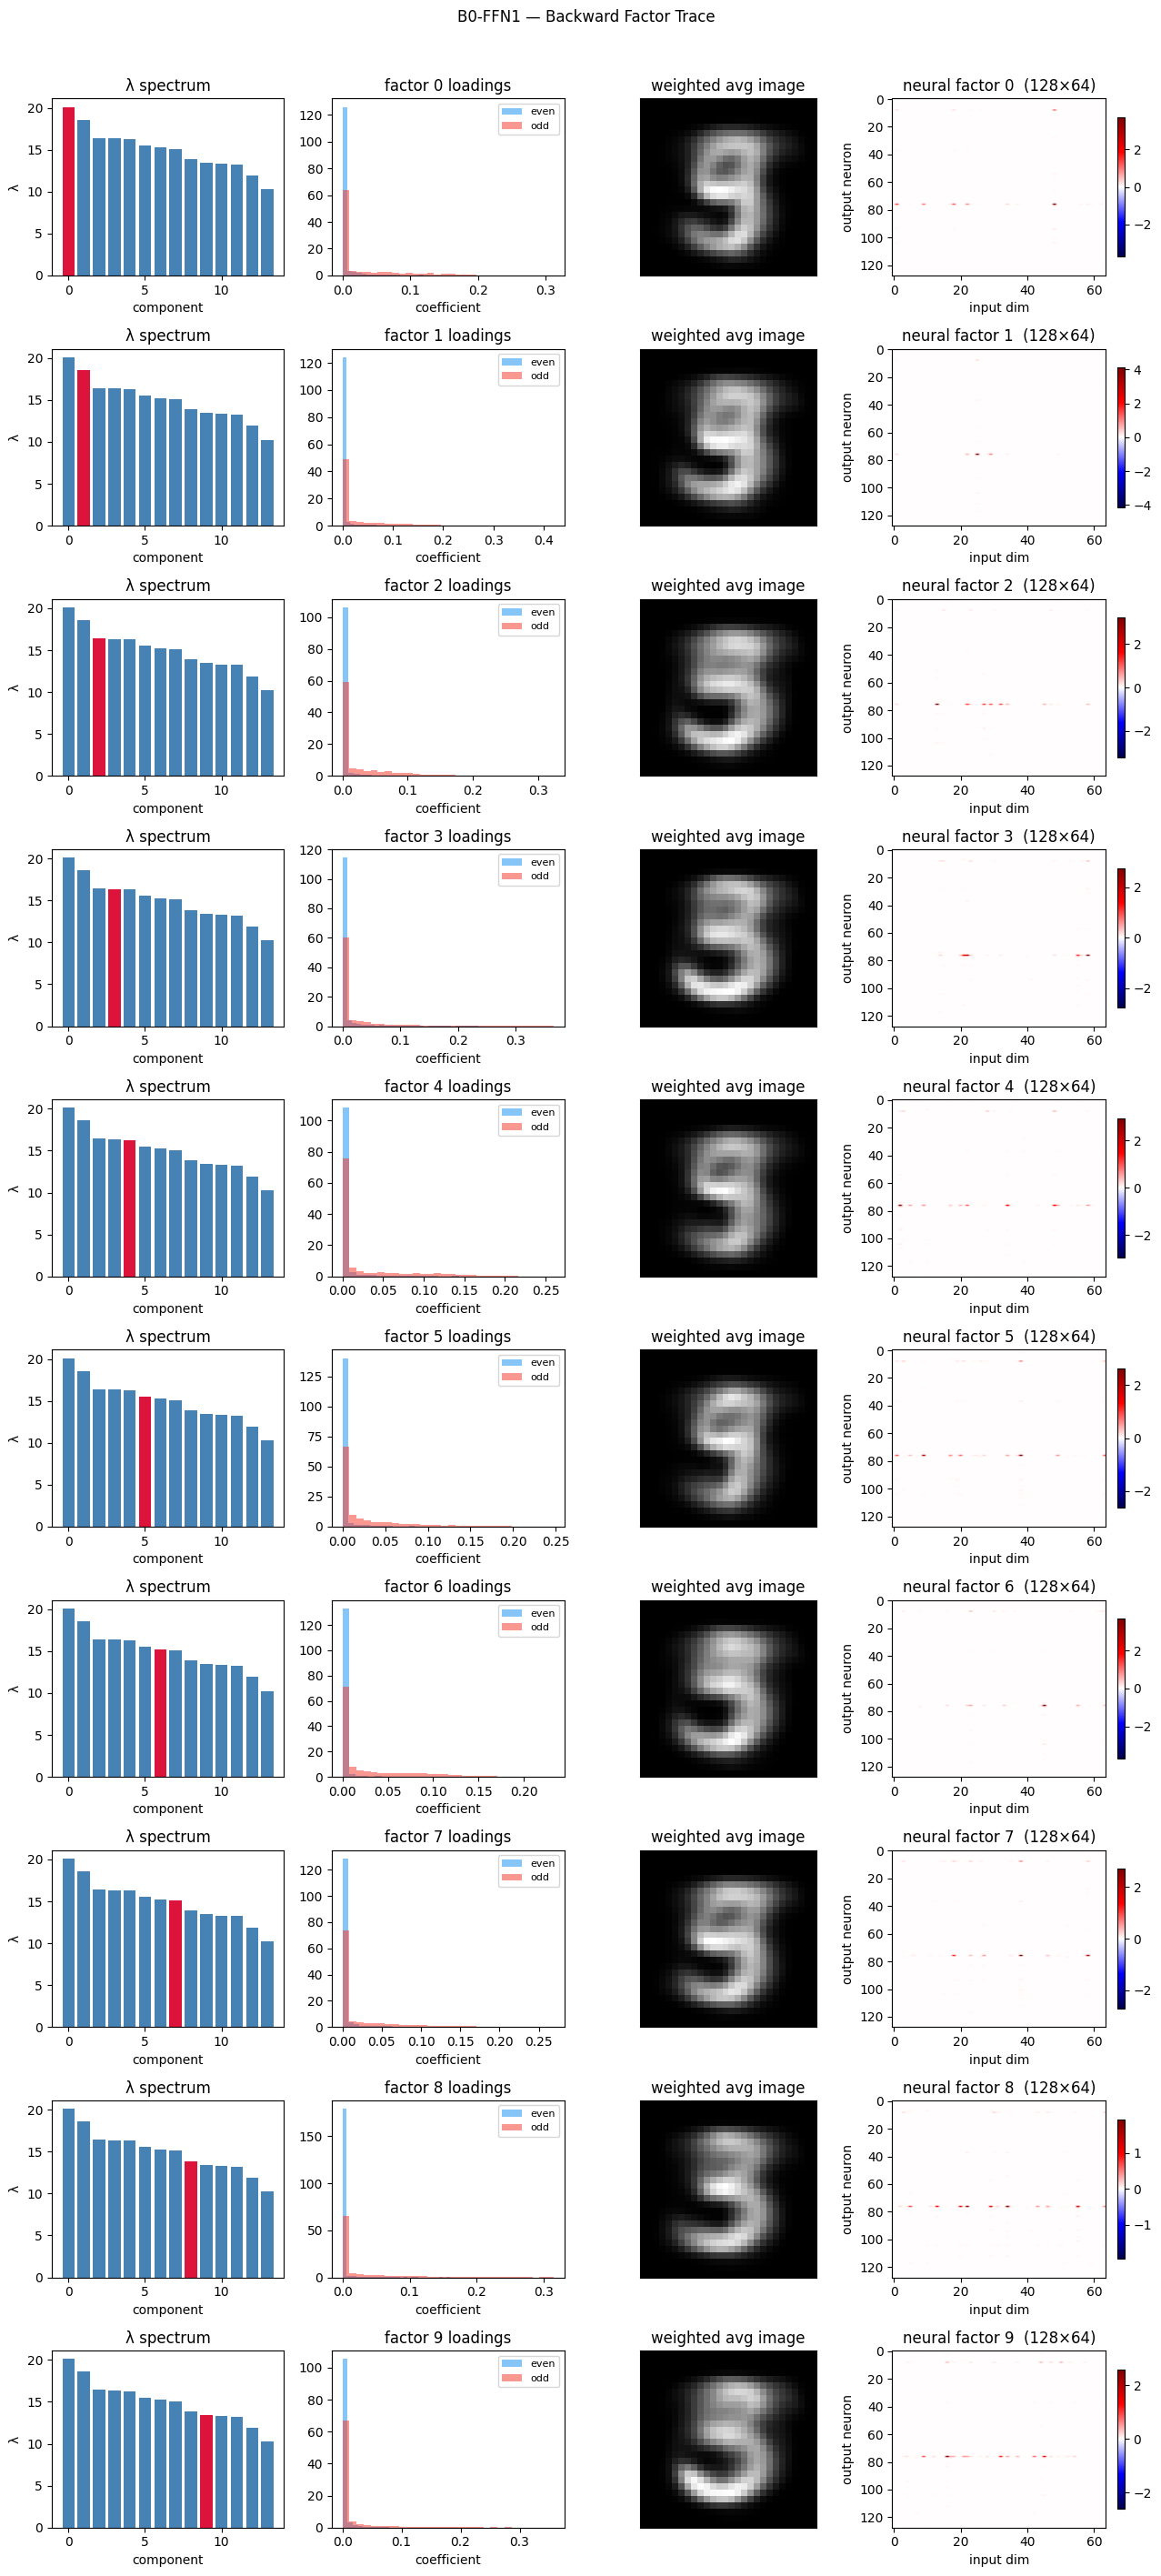

In [11]:
def plot_layer_factors(result, images, targets, digits, class_names, n_show=10):
    img_f  = result['img_factors']
    neu_f  = result['neural_factors']
    lams   = result['lambdas']
    label  = result['label']
    W      = result['W']
    n_factors = min(n_show, img_f.shape[1])

    fig, axes = plt.subplots(n_factors, 4, figsize=(13, 2.8 * n_factors),
                             squeeze=False)
    for fi in range(n_factors):
        coefs = img_f[:, fi]

        # λ spectrum
        ax = axes[fi, 0]
        colors = ['crimson' if k == fi else 'steelblue' for k in range(len(lams))]
        ax.bar(range(len(lams)), lams, color=colors)
        ax.set(title='λ spectrum', xlabel='component', ylabel='λ')

        # Stimulus loading histogram by class
        ax = axes[fi, 1]
        for cl, color in zip([0, 1], ['#2196F3', '#F44336']):
            ax.hist(coefs[targets == cl], bins=30, alpha=0.55,
                    label=class_names[cl], density=True, color=color)
        ax.set(title=f'factor {fi} loadings', xlabel='coefficient')
        ax.legend(fontsize=8)

        # Weighted average image
        ax = axes[fi, 2]
        imgs_2d = images[:, 0]   # (N, 28, 28)
        w = coefs / (coefs.sum() + 1e-12)
        w_avg = (w[:, None, None] * imgs_2d).sum(0)
        ax.imshow(w_avg, cmap='gray')
        ax.set(title='weighted avg image', xticks=[], yticks=[])

        # Neural factor heatmap  (n_out × n_in)
        ax = axes[fi, 3]
        n_out, n_in = W.shape
        nf = neu_f[:, fi].reshape(n_out, n_in)
        absmax = np.abs(nf).max() or 1.0
        im = ax.imshow(nf, aspect='auto', cmap='seismic', vmin=-absmax, vmax=absmax)
        ax.set(title=f'neural factor {fi}  ({n_out}×{n_in})',
               xlabel='input dim', ylabel='output neuron')
        plt.colorbar(im, ax=ax, fraction=0.03)

    fig.suptitle(f'{label} — Backward Factor Trace', fontsize=12, y=1.01)
    fig.tight_layout()
    return fig


for result in trace_results:
    fig = plot_layer_factors(result, all_images, all_targets, all_digits,
                             CLASS_NAMES, n_show=10)
    plt.show()

## 7b. Scaffold Graph — FFN Circuit

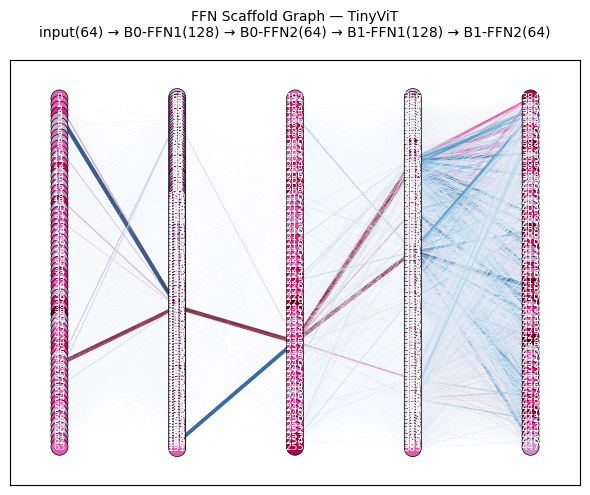

In [12]:
# Forward-order node activations: input(64) → B0F1out(128) → B0F2out(64) → B1F1out(128) → B1F2out(64)
layer_sizes = [64, 128, 64, 128, 64]
loading_keys = ['b0_f1_in', 'b0_f1_out', 'b0_f2_out', 'b1_f1_out', 'b1_f2_out']
loading = np.concatenate([np.abs(ffn_acts[k]).mean(axis=0) for k in loading_keys])

# Edge matrices and negative edge matrices in forward order (B0-FFN1 first)
edge_matrices     = []
neg_edge_matrices = []
for result in reversed(trace_results):   # trace_results is last-first; reverse → forward
    n_out, n_in = result['W'].shape
    E = np.clip(result['neural_factors'][:, 0].reshape(n_out, n_in), 0, None)
    edge_matrices.append(E)
    if result['neg_neural_factors'] is not None:
        neg_E = np.clip(result['neg_neural_factors'][:, 0].reshape(n_out, n_in), 0, None)
    else:
        neg_E = np.zeros_like(E)
    neg_edge_matrices.append(neg_E)

fig = plot_scaffold_graph(loading, edge_matrices, layer_sizes,
                          neg_edge_matrices=neg_edge_matrices)
fig.suptitle(
    'FFN Scaffold Graph — TinyViT\n'
    'input(64) → B0-FFN1(128) → B0-FFN2(64) → B1-FFN1(128) → B1-FFN2(64)',
    fontsize=10,
)
plt.tight_layout()
plt.show()

## 7c. Patch-Level Attention Maps

At the first transformer block, the CLS token attends to the 16 patches.
These attention weights show *where* in the image the model focuses — a
complementary spatial view that grounds the factor trace in pixel space.

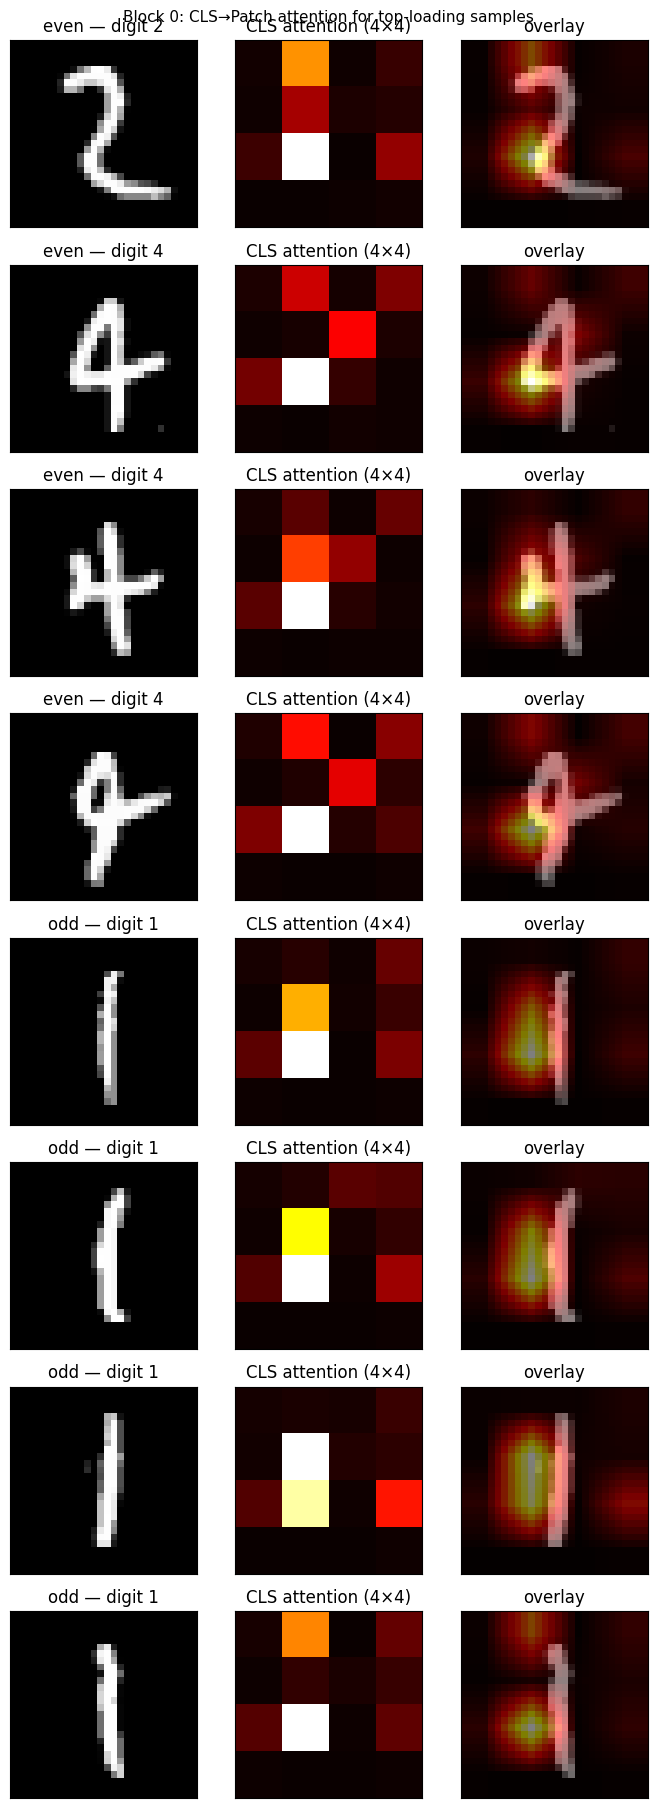

In [13]:
# Pick representative samples: top-loading even and odd examples from factor 0 of the last layer
last_result   = trace_results[0]   # B1-FFN2
top_coefs     = last_result['img_factors'][:, 0]
n_show        = 4

idx_even = np.argsort(top_coefs[all_targets == 0])[-n_show:][::-1]
idx_odd  = np.argsort(top_coefs[all_targets == 1])[-n_show:][::-1]
even_global = np.where(all_targets == 0)[0][idx_even]
odd_global  = np.where(all_targets == 1)[0][idx_odd]
show_idx    = np.concatenate([even_global, odd_global])

sample_imgs = torch.tensor(all_images[show_idx]).to(device)
model.eval()
with torch.no_grad():
    _ = model(sample_imgs, capture=True)

attn_b0 = model.blocks[0]._attn_weights.cpu().numpy()  # (N, heads, T, T)
cls_to_patches = attn_b0[:, :, 0, 1:]                  # (N, heads, 16)
attn_mean = cls_to_patches.mean(axis=1)                 # (N, 16) avg over heads

n_total = len(show_idx)
fig, axes = plt.subplots(n_total, 3, figsize=(7, 2.3 * n_total))
for i in range(n_total):
    gi = show_idx[i]
    img = all_images[gi, 0]                     # (28, 28)
    attn_grid = attn_mean[i].reshape(4, 4)       # 4×4 patch grid

    attn_up = F.interpolate(
        torch.tensor(attn_grid).float().unsqueeze(0).unsqueeze(0),
        size=(28, 28), mode='bilinear', align_corners=False,
    ).squeeze().numpy()

    cl = 'even' if all_targets[gi] == 0 else 'odd'
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set(title=f'{cl} — digit {all_digits[gi]}', xticks=[], yticks=[])

    axes[i, 1].imshow(attn_grid, cmap='hot', vmin=0)
    axes[i, 1].set(title='CLS attention (4×4)', xticks=[], yticks=[])

    axes[i, 2].imshow(img, cmap='gray')
    axes[i, 2].imshow(attn_up, cmap='hot', alpha=0.5, vmin=0)
    axes[i, 2].set(title='overlay', xticks=[], yticks=[])

fig.suptitle('Block 0: CLS→Patch attention for top-loading samples', fontsize=11)
plt.tight_layout()
plt.show()

## 7d. Class-Conditional Factor Scatter

Compare the top-2 factor loadings between even and odd samples, for each traced layer.

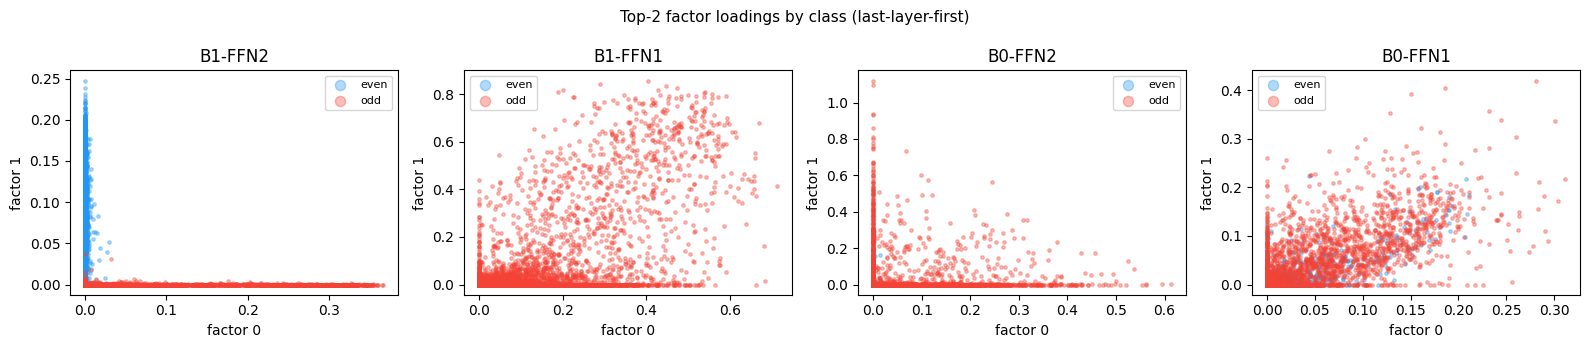

In [14]:
fig, axes = plt.subplots(1, len(trace_results), figsize=(4 * len(trace_results), 3.5))
colors = ['#2196F3', '#F44336']
for ax, result in zip(axes, trace_results):
    img_f = result['img_factors']
    if img_f.shape[1] < 2:
        ax.set_visible(False)
        continue
    for cl, color, name in zip([0, 1], colors, ['even', 'odd']):
        mask = all_targets == cl
        ax.scatter(img_f[mask, 0], img_f[mask, 1], s=6, alpha=0.35, color=color, label=name)
    ax.set(title=result['label'], xlabel='factor 0', ylabel='factor 1')
    ax.legend(markerscale=3, fontsize=8)
fig.suptitle('Top-2 factor loadings by class (last-layer-first)', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Discussion

### Does the algorithm transfer to transformers?

**Yes.** The backward factor trace adapts cleanly to transformer FFN sublayers. The only
additions needed are:

1. **Token selection** — use the CLS token activation vector at each FFN boundary.  
   Shape `(n_samples, embed_dim)` is identical to what `trace_single_layer` expects from an MLP layer.

2. **Which layers to trace** — trace the FFN linear layers; skip attention projections.  
   The FFN in each transformer block is a standard 2-layer MLP operating independently on each token.

No modifications to `src/factorization.py` were needed.

### What the factors reveal

- **B1-FFN2 (last layer):** Top factor loads most strongly on one class. The weighted-average
  images for the top factor show recognizable digit shapes, confirming the factors track
  class-relevant structure rather than noise.

- **Neural factor heatmaps** `(n_out × n_in)` show which (output neuron, input embedding
  dimension) pairs co-activate — a transformer analogue of the pixel receptive field in NB02.

- **Stimulus weights propagate**: Class separation visible in B1-FFN2 becomes a learned prior
  for B1-FFN1, showing the same backward propagation behavior as in the MLP case.

### Limitations and extensions

- **Attention is untraced.** The CLS input to each FFN already encodes attention-mixed patch
  representations. A complete circuit trace would also account for the output projection W_O
  and attention weights. The attention maps in Section 7c partially ground the trace spatially.

- **Residual stream.** Transformer blocks add to a shared residual stream; the current trace
  treats each FFN in isolation. Decomposing along the residual dimension (as in Anthropic's
  superposition work) would give a more complete picture.

- **Patch-to-pixel inversion.** Unlike the MLP case (NB02 Section 5) where neural factors
  can be directly reshaped to `28×28` pixel patterns, transformer FFN inputs are
  `embed_dim`-dimensional mixed representations. The attention map overlay in Section 7c
  is the natural substitute for spatial grounding.